# Autoregressive Model of Stock Returns


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
average = 0.0006
std = 0.013
rng = np.random.default_rng(seed=100)
innovations = rng.normal(size=100, scale=std)

factors = [0.7, -0.3, 0.5]

sample_data = np.zeros(innovations.shape[0], dtype=float)
sample_data[:3] = average + std*innovations[:3]
for ii in range(3, sample_data.shape[0]):
    sample_data[ii] = np.dot(np.concatenate(([1], factors)),
                             np.concatenate(([average], sample_data[np.flip(np.arange(3))+ii-3]))) + innovations[ii]

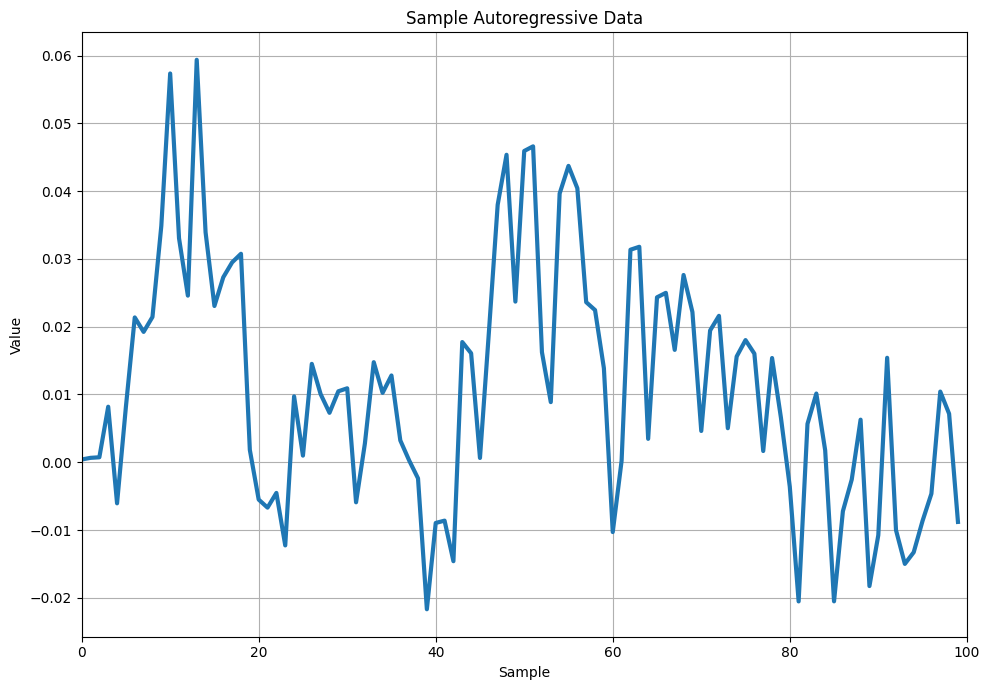

In [3]:
plt.figure(figsize=(10,7))
plt.plot(sample_data, linewidth=3); plt.grid()
plt.xlabel('Sample'); plt.ylabel('Value')
plt.xlim(left=0, right=sample_data.shape[0])
plt.title('Sample Autoregressive Data')
plt.tight_layout()

In [49]:
ar_fit_matrix = np.zeros((50,4), dtype=float)
ar_fit_matrix[:,0] += 1
ar_fit_matrix[:,1] = sample_data[np.arange(ar_fit_matrix.shape[0])+2]
ar_fit_matrix[:,2] = sample_data[np.arange(ar_fit_matrix.shape[0])+1]
ar_fit_matrix[:,3] = sample_data[np.arange(ar_fit_matrix.shape[0])]

fit_data = sample_data[np.arange(ar_fit_matrix.shape[0])+4]

In [50]:
fit_factors = np.linalg.pinv(ar_fit_matrix)@fit_data[...,np.newaxis]

reconstructed_data = ar_fit_matrix@fit_factors
residual = fit_data-reconstructed_data[:,0]

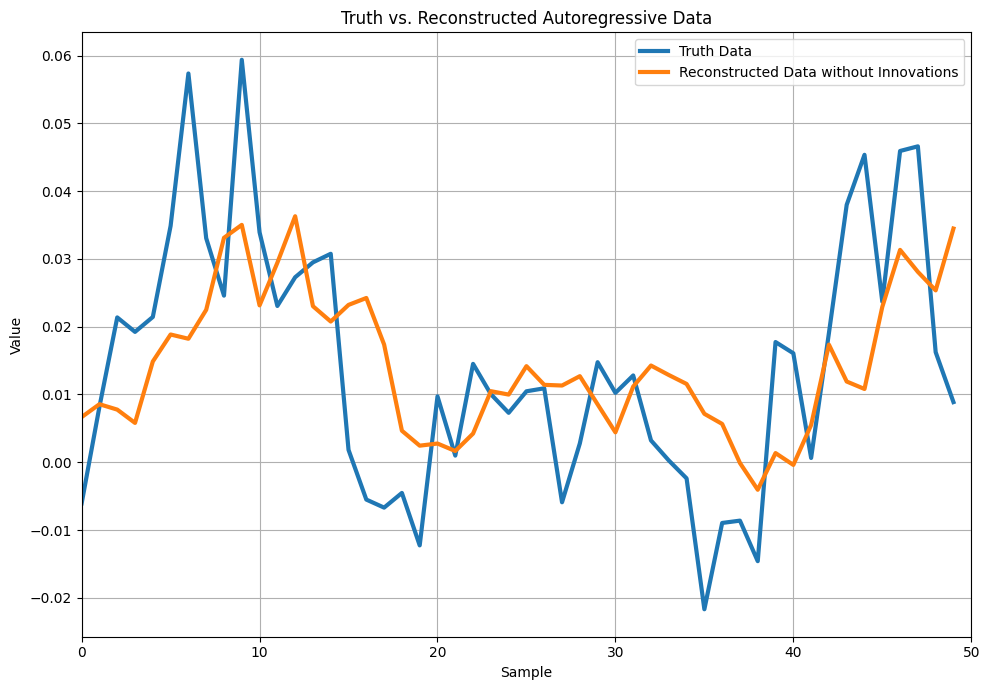

In [51]:
plt.figure(figsize=(10,7))
plt.plot(fit_data, linewidth=3, label='Truth Data'); 
plt.plot(reconstructed_data, linewidth=3, label='Reconstructed Data without Innovations')
plt.grid(); plt.legend(); plt.xlabel('Sample'); plt.ylabel('Value')
plt.xlim(left=0, right=fit_data.shape[0]); 
plt.title('Truth vs. Reconstructed Autoregressive Data')
plt.tight_layout()

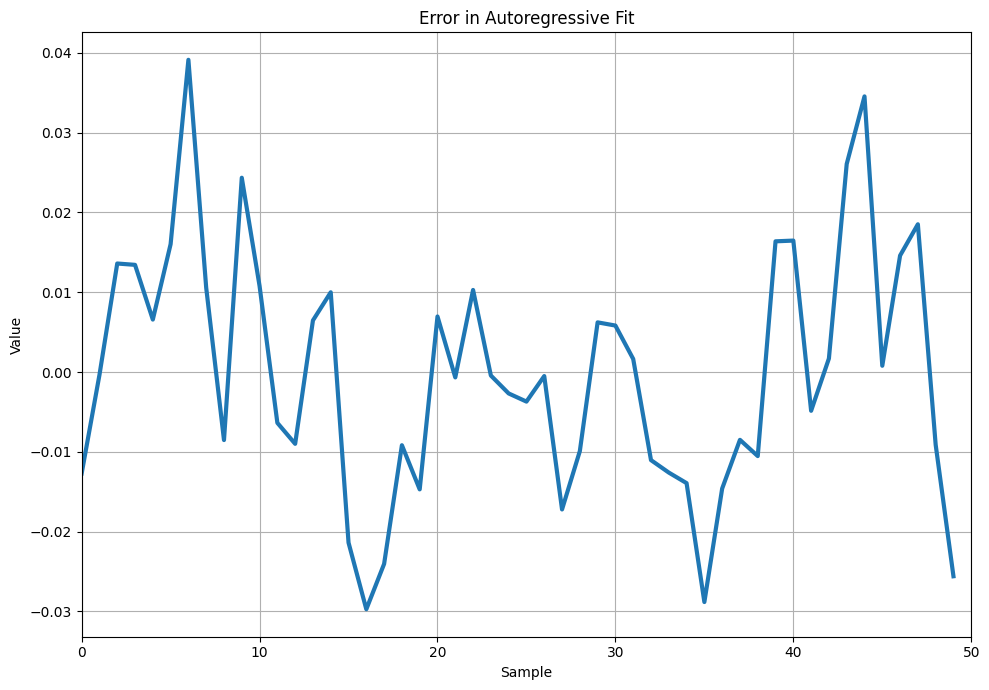

In [52]:
plt.figure(figsize=(10,7))
plt.plot(residual, linewidth=3); 
plt.grid(); plt.xlabel('Sample'); plt.ylabel('Value')
plt.xlim(left=0, right=fit_data.shape[0]); 
plt.title('Error in Autoregressive Fit')
plt.tight_layout()

In [53]:
sigma_a = np.sqrt(np.sum(residual**2)/(residual.shape[0]-2*3-1))

In [69]:
fit_innovations = np.random.randn(innovations.shape[0])*sigma_a
ar_data = np.zeros(innovations.shape[0], dtype=float)
ar_data[:3] = sample_data[:3]
for ii in range(3, sample_data.shape[0]):
    ar_data[ii] = np.dot(np.concatenate(([1], fit_factors[1:,0])),
                         np.concatenate(([fit_factors[0,0]], ar_data[np.flip(np.arange(3))+ii-3]))) + fit_innovations[ii]

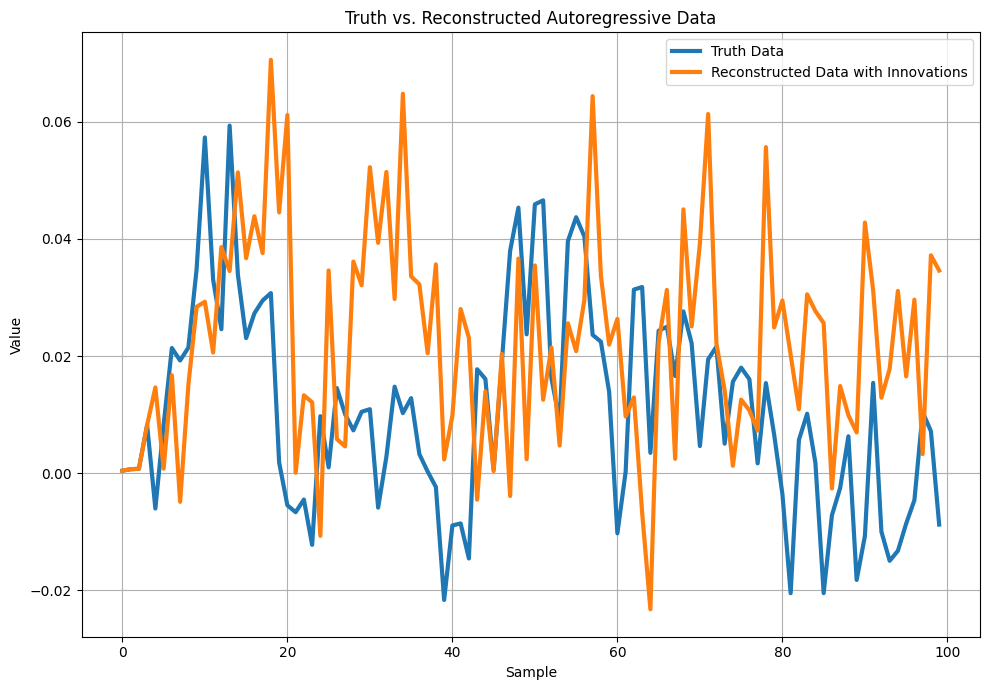

In [70]:
plt.figure(figsize=(10,7))
plt.plot(sample_data, linewidth=3, label='Truth Data'); 
plt.plot(ar_data, linewidth=3, label='Reconstructed Data with Innovations')
plt.grid(); plt.legend(); plt.xlabel('Sample'); plt.ylabel('Value')
#plt.xlim(left=0, right=fit_data.shape[0]); 
plt.title('Truth vs. Reconstructed Autoregressive Data')
plt.tight_layout()